In [3]:
%pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# RetailPulse – Customer Segmentation

## Machine Learning using K-Means Clustering

**Author:** Gulafsha

### Objective
This notebook performs customer segmentation using K-Means Clustering based on RFM (Recency, Frequency, Monetary) and additional customer behavioral features.

### Goals
- Load the feature-engineered customer dataset.
- Standardize numerical features.
- Identify the optimal number of customer clusters.
- Segment customers into meaningful groups.
- Generate insights for marketing and business decision-making.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


## Load Feature Engineered Dataset

The dataset created in Notebook 03 (`customer_features.csv`) is loaded for customer segmentation.

In [30]:
rfm = pd.read_csv("../data/rfm_features.csv")

print("Dataset Loaded Successfully ✅")

rfm.head()

Dataset Loaded Successfully ✅


,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,165,11,372.86,70,372.86,11,26,33.896364
1,3,2,1323.32,828,1323.32,2,70,661.660000
2,74,1,222.16,373,222.16,1,20,222.160000
3,43,3,2671.14,993,2671.14,3,90,890.380000
4,11,1,300.93,261,300.93,1,21,300.930000


## Load the Feature Engineered Dataset

This dataset was created in Notebook 03 after performing feature engineering.
It contains customer-level features that will be used for clustering.

In [7]:
rfm = pd.read_csv("../data/customer_features.csv")

print("Dataset Loaded Successfully ✅")

rfm.head()

Dataset Loaded Successfully ✅


,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000


## Explore the Dataset

Before applying Machine Learning, we inspect the dataset structure,
column names, and missing values.

In [8]:
print("Shape:", rfm.shape)

rfm.info()

rfm.describe().round(2)

Shape: (4312, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer ID          4312 non-null   float64
 1   Recency              4312 non-null   int64  
 2   Frequency            4312 non-null   int64  
 3   Monetary             4312 non-null   float64
 4   Total_Quantity       4312 non-null   int64  
 5   Total_Revenue        4312 non-null   float64
 6   Invoice_Count        4312 non-null   int64  
 7   Unique_Products      4312 non-null   int64  
 8   Average_Order_Value  4312 non-null   float64
dtypes: float64(4), int64(5)
memory usage: 303.3 KB


,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
count,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00
mean,15349.29,91.17,4.46,2040.41,1280.05,2040.41,4.46,63.65,376.37
std,1701.20,96.86,8.17,8911.76,6457.93,8911.76,8.17,85.76,492.36
min,12346.00,1.00,1.00,2.95,1.00,2.95,1.00,1.00,2.95
25%,13882.50,18.00,1.00,307.19,156.00,307.19,1.00,17.00,179.49
50%,15350.50,53.00,2.00,701.62,380.00,701.62,2.00,38.00,285.05
75%,16834.25,136.00,5.00,1714.93,992.00,1714.93,5.00,79.25,421.48
max,18287.00,374.00,205.00,349164.35,220600.00,349164.35,205.00,1741.00,11880.84


In [9]:
rfm.rename(columns={"Unnamed: 0": "Customer_ID"}, inplace=True)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000


## Select Features for Clustering

Only customer behavioural features are used for K-Means.
Customer_ID is excluded because it is an identifier.

In [10]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Invoice_Count",
    "Unique_Products",
    "Average_Order_Value"
]

X = rfm[features]

X.head()

,Recency,Frequency,Monetary,Total_Quantity,Invoice_Count,Unique_Products,Average_Order_Value
0,165,11,372.86,70,11,26,33.896364
1,3,2,1323.32,828,2,70,661.660000
2,74,1,222.16,373,1,20,222.160000
3,43,3,2671.14,993,3,90,890.380000
4,11,1,300.93,261,1,21,300.930000


## Feature Scaling

K-Means clustering is distance-based.
Standardization ensures that all features contribute equally to clustering.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Standardized Successfully ✅")

Data Standardized Successfully ✅


In [12]:
print(X_scaled.shape)

(4312, 7)


In [13]:
print(rfm.shape)

(4312, 9)


In [14]:
print(X_scaled.shape)

(4312, 7)


## Elbow Method

The Elbow Method helps determine the optimal number of clusters (K) for K-Means.

The model is trained using different values of K, and the Within-Cluster Sum of Squares (WCSS) is calculated.

The point where the decrease in WCSS starts slowing down is called the "elbow" and indicates the optimal number of clusters.

In [15]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

## Elbow Curve

The elbow curve visualizes the relationship between the number of clusters and WCSS.
The optimal K is selected where the curve begins to flatten.

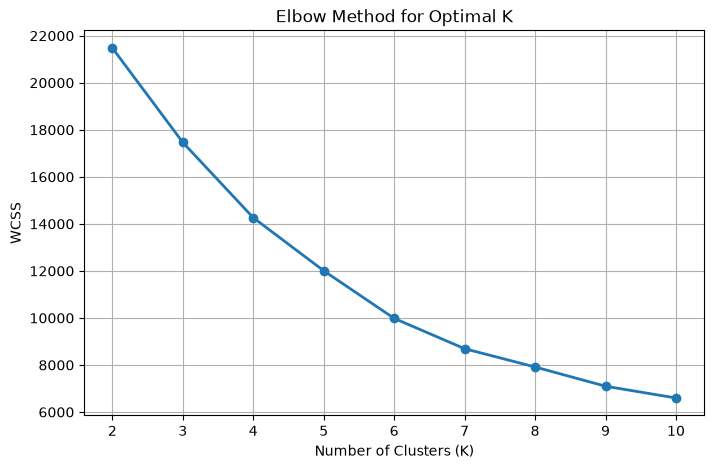

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o", linewidth=2)

plt.title("Elbow Method for Optimal K")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

## Train the K-Means Model

Based on the Elbow Method, the optimal number of clusters is selected as K = 5.

The K-Means algorithm groups customers with similar purchasing behaviour into five distinct clusters.

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means Model Trained Successfully ✅")

K-Means Model Trained Successfully ✅


## Cluster Distribution

The following output shows the number of customers assigned to each cluster.

In [18]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1027
1      12
2       8
3    2846
4     419
Name: count, dtype: int64

In [19]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value,Cluster
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364,0
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000,3
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000,3
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000,3
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000,3


## Cluster Profiling

The average values of each feature are calculated for every cluster to understand customer behaviour.

In [31]:
# Save cluster summary
cluster_summary.to_csv(
    "../outputs/cluster_summary.csv"
)

print("✅ cluster_summary.csv saved successfully!")

✅ cluster_summary.csv saved successfully!


In [21]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1027
1      12
2       8
3    2846
4     419
Name: count, dtype: int64

In [36]:
cluster_summary = (
    rfm.groupby("Cluster")[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Total_Quantity",
            "Invoice_Count",
            "Unique_Products",
            "Average_Order_Value"
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

KeyError: 'Cluster'

## Assign Business Labels

The numeric cluster IDs are converted into meaningful business segments to make
the results easier for business users to understand.

In [25]:
segment_map = {
    0: "Lost Customers",
    1: "VIP Customers",
    2: "High-Value Customers",
    3: "Regular Customers",
    4: "Loyal Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value,Cluster,Customer_Segment
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364,0,Lost Customers
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000,3,Regular Customers
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000,3,Regular Customers
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000,3,Regular Customers
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000,3,Regular Customers


In [26]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Regular Customers       2846
Lost Customers          1027
Loyal Customers          419
VIP Customers             12
High-Value Customers       8
Name: count, dtype: int64

## Customer Segment Distribution

This chart shows the number of customers in each business segment identified by the K-Means clustering model.

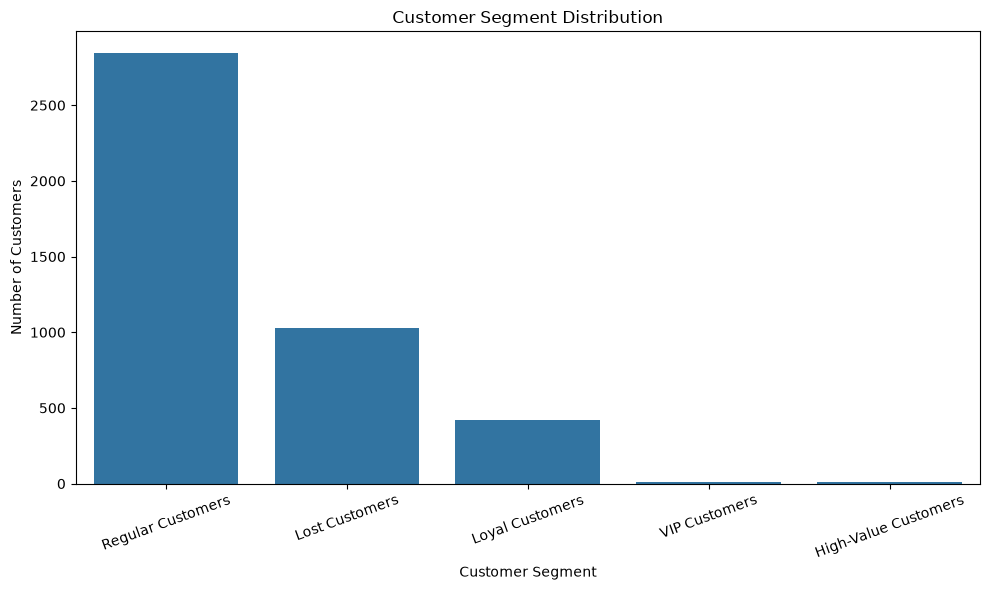

In [27]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x="Customer_Segment",
    order=rfm["Customer_Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [29]:
rfm.to_csv("../outputs/rfm_segments.csv", index=False)

print("✅ rfm_segments.csv saved successfully!")

✅ rfm_segments.csv saved successfully!


In [1]:
import pandas as pd

df = pd.read_csv(r"D:\RetailPulse\data\customer_segments.csv")
print(df.columns.tolist())
print(df.head())

['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Total_Revenue', 'Invoice_Count', 'Unique_Products', 'Average_Order_Value', 'Cluster', 'Customer_Segment']
   Customer ID  Recency  Frequency  Monetary  Total_Quantity  Total_Revenue  \
0      12346.0      165         11    372.86              70         372.86   
1      12347.0        3          2   1323.32             828        1323.32   
2      12348.0       74          1    222.16             373         222.16   
3      12349.0       43          3   2671.14             993        2671.14   
4      12351.0       11          1    300.93             261         300.93   

   Invoice_Count  Unique_Products  Average_Order_Value  Cluster  \
0             11               26            33.896364        0   
1              2               70           661.660000        3   
2              1               20           222.160000        3   
3              3               90           890.380000        3   
4            